# AD2C Experiment Plots

Four sections:
1. **Download** — fetch all W&B run histories (navigation, balance, convergence, stability)
2. **Plot 1** — Combined Navigation + Balance results (2x3 grid)
3. **Plot 2** — Convergence analysis (varying initial SND)
4. **Plot 3** — Stability analysis (ESC on vs off)

In [3]:
import pandas as pd
import wandb
import os

api = wandb.Api()

# -- Helper -------------------------------------------------------

def download_runs(project, run_map, output_dir):
    """
    run_map: dict of  output_filename (no ext) -> W&B run name
    Downloads each run's history and saves as CSV.
    """
    os.makedirs(output_dir, exist_ok=True)
    runs = api.runs(project)
    lookup = {r.name: r for r in runs}
    print(f"  {project}: {len(lookup)} runs found")

    for fname, run_name in run_map.items():
        if run_name not in lookup:
            print(f"    MISSING: {run_name}")
            continue
        df = lookup[run_name].history(samples=10000)
        path = os.path.join(output_dir, f"{fname}.csv")
        df.to_csv(path, index=False)
        print(f"    {run_name} -> {path} ({len(df)} rows)")


# ==================================================================
# NAVIGATION
# ==================================================================
NAV_PROJECT = "svarp-university-of-massachusetts-lowell/Navigation"
nav_runs = {}

# --- AD2C (5 seeds each) ---
# 3A-3G: nav_ad2c_3a3g_0_seed{s}
# 3A-2G: 3agent2goal_seed{s}  (old naming)
# 3A-1G: 3agent1goal_seed{s}  (old naming)
for s in range(5):
    nav_runs[f"ad2c_3A-3G_seed{s}"] = f"nav_ad2c_3a3g_0_seed{s}"
    nav_runs[f"ad2c_3A-2G_seed{s}"] = f"3agent2goal_seed{s}"
    nav_runs[f"ad2c_3A-1G_seed{s}"] = f"3agent1goal_seed{s}"

# --- DiCo fine-tuned (5 seeds each) ---
# 3A-3G SND=1.0, 3A-2G SND=0.8, 3A-1G SND=0
for s in range(5):
    nav_runs[f"dico_3A-3G_seed{s}"] = f"nav_dico_3a3g_1_seed{s}"
    nav_runs[f"dico_3A-2G_seed{s}"] = f"nav_dico_3a2g_0.8_seed{s}"
    nav_runs[f"dico_3A-1G_seed{s}"] = f"nav_dico_3a1g_0_seed{s}"

# --- Unconstrained (SND=-1, 5 seeds each) ---
for s in range(5):
    nav_runs[f"unconstrained_3A-3G_seed{s}"] = f"nav_ad2c_3a3g_-1_seed{s}"
    nav_runs[f"unconstrained_3A-2G_seed{s}"] = f"nav_ad2c_3a2g_-1_seed{s}"
    nav_runs[f"unconstrained_3A-1G_seed{s}"] = f"nav_ad2c_3a1g_-1_seed{s}"

print("Downloading Navigation data...")
download_runs(NAV_PROJECT, nav_runs, "navigation_data")


# ==================================================================
# BALANCE
# ==================================================================
BAL_PROJECT = "svarp-university-of-massachusetts-lowell/Balance"
bal_runs = {}

# --- AD2C (5 seeds each) ---
for mass in ["4", "3", "2"]:
    for s in range(5):
        bal_runs[f"ad2c_{mass}M_seed{s}"] = f"balance_3a{mass}Mass_seed{s}"

# --- DiCo fine-tuned (SND=0 for all Balance, 5 seeds each) ---
for mass in ["4", "3", "2"]:
    for s in range(5):
        bal_runs[f"dico_{mass}M_seed{s}"] = f"Balance_dico_3a{mass}mass_0_seed{s}"

# --- Unconstrained (5 seeds each) ---
for mass in ["4", "3", "2"]:
    for s in range(5):
        bal_runs[f"unconstrained_{mass}M_seed{s}"] = f"Balance_ad2c_3a{mass}mass_-1_seed{s}"

print("\nDownloading Balance data...")
download_runs(BAL_PROJECT, bal_runs, "balance_data")


# ==================================================================
# CONVERGENCE  (AD2C 3A-3G with different initial SND setpoints)
# ==================================================================
conv_runs = {}

# AD2C starting from SND = 0, 0.5, 1.0
for snd in ["0", "0.5", "1"]:
    for s in range(5):
        conv_runs[f"conv_snd{snd}_seed{s}"] = f"nav_ad2c_3a3g_{snd}_seed{s}"

# DiCo fixed baselines for comparison
for s in range(5):
    conv_runs[f"dico_snd1_seed{s}"] = f"nav_dico_3a3g_1_seed{s}"
for s in range(4):
    conv_runs[f"dico_snd0_seed{s}"] = f"nav_dico_3a3g_0_seed{s}"
for s in [0, 2]:
    conv_runs[f"dico_snd0p5_seed{s}"] = f"nav_dico_3a3g_0.5_seed{s}"

print("\nDownloading Convergence data...")
download_runs(NAV_PROJECT, conv_runs, "convergence_data")


# ==================================================================
# STABILITY  (ESC off after convergence, Navigation only)
# ==================================================================
stab_runs = {}
for task, goals in [("3A-3G", "3"), ("3A-2G", "2"), ("3A-1G", "1")]:
    for s in range(5):
        stab_runs[f"stable_{task}_seed{s}"] = f"stable_ad2c_3a{goals}g_seed{s}"

print("\nDownloading Stability data...")
download_runs(NAV_PROJECT, stab_runs, "stability_data")

print("\nAll downloads complete.")

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/grad/doc/2027/spatel2/.netrc.


  svarp-university-of-massachusetts-lowell/Navigation: 127 runs found
    nav_ad2c_3a3g_0_seed0 -> navigation_data/ad2c_3A-3G_seed0.csv (200 rows)
    3agent2goal_seed0 -> navigation_data/ad2c_3A-2G_seed0.csv (200 rows)
    3agent1goal_seed0 -> navigation_data/ad2c_3A-1G_seed0.csv (200 rows)
    nav_ad2c_3a3g_0_seed1 -> navigation_data/ad2c_3A-3G_seed1.csv (200 rows)
    3agent2goal_seed1 -> navigation_data/ad2c_3A-2G_seed1.csv (200 rows)
    3agent1goal_seed1 -> navigation_data/ad2c_3A-1G_seed1.csv (200 rows)
    nav_ad2c_3a3g_0_seed2 -> navigation_data/ad2c_3A-3G_seed2.csv (200 rows)
    3agent2goal_seed2 -> navigation_data/ad2c_3A-2G_seed2.csv (200 rows)
    3agent1goal_seed2 -> navigation_data/ad2c_3A-1G_seed2.csv (200 rows)
    nav_ad2c_3a3g_0_seed3 -> navigation_data/ad2c_3A-3G_seed3.csv (200 rows)
    3agent2goal_seed3 -> navigation_data/ad2c_3A-2G_seed3.csv (200 rows)
    3agent1goal_seed3 -> navigation_data/ad2c_3A-1G_seed3.csv (200 rows)
    nav_ad2c_3a3g_0_seed4 -> navigatio

---
# Shared Helpers
Run this cell before any plot section.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.lines as mlines
import glob, os

matplotlib.rcParams.update({
    'font.family': 'serif',
    # 'font.serif': ['Palatino', 'Palatino Linotype', 'Book Antiqua', 'DejaVu Serif'],
    'font.sans-serif': ['Arial'],
    'text.usetex': False,
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'legend.fontsize': 7,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linewidth': 0.4,
    'axes.facecolor': '#fafafa',
})

# -- Column names --------------------------------------------------

STEP      = "_step"
SND       = "eval/agents/snd"
REWARD    = "eval/agents/reward/episode_reward_mean"
EPL       = "eval/reward/episode_len_mean"
SETPOINT  = "esc/snd_setpoint"

METRICS = {"snd": SND, "reward": REWARD, "epl": EPL}

LINE_STYLES = {
    "ad2c":          dict(linestyle="-",            linewidth=1.0, alpha=1.0),
    "dico":          dict(linestyle="-.",       linewidth=1.0, alpha=0.95),
    "unconstrained": dict(linestyle="--",   linewidth=1.0, alpha=0.95),
}

# -- Smoothing & aggregation ---------------------------------------

def smooth(y, w=5):
    if w <= 1 or len(y) < w:
        return y
    k = np.ones(w) / w
    p = np.pad(y, (w // 2, w // 2), mode='edge')
    return np.convolve(p, k, mode='valid')[:len(y)]


def aggregate(dfs, col, n_pts=500, sw=5):
    """Interpolate multiple seed DataFrames onto a common grid. Returns mean +/- std."""
    valid = []
    for df in dfs:
        if col in df.columns and STEP in df.columns:
            sub = df[[STEP, col]].dropna().sort_values(STEP)
            if len(sub) >= 2:
                valid.append(sub)
    if not valid:
        return None, None, None, None
    lo = max(s[STEP].min() for s in valid)
    hi = min(s[STEP].max() for s in valid)
    steps = np.linspace(lo, hi, n_pts)
    interp = np.array([np.interp(steps, s[STEP].values, s[col].values) for s in valid])
    if col == EPL:
        interp = np.clip(interp, None, 100)
    mean = smooth(interp.mean(0), sw)
    std = smooth(interp.std(0), sw)
    lo_band = np.maximum(mean - std, 0)
    hi_band = mean + std
    if col == EPL:
        hi_band = np.minimum(hi_band, 100)
    return steps, mean, lo_band, hi_band


def aggregate_setpoint(dfs, n_pts=500):
    """Aggregate ESC setpoint across seeds."""
    valid = []
    for df in dfs:
        if SETPOINT in df.columns and STEP in df.columns:
            sub = df[[STEP, SETPOINT]].dropna().sort_values(STEP)
            if len(sub) >= 2:
                valid.append(sub)
    if not valid:
        return None, None
    lo = max(s[STEP].min() for s in valid)
    hi = min(s[STEP].max() for s in valid)
    steps = np.linspace(lo, hi, n_pts)
    interp = np.array([np.interp(steps, s[STEP].values, s[SETPOINT].values) for s in valid])
    return steps, smooth(interp.mean(0), 11)


def load_csvs(data_dir, prefix):
    """Load all CSVs matching data_dir/prefix*.csv."""
    files = sorted(glob.glob(os.path.join(data_dir, f"{prefix}*.csv")))
    return [pd.read_csv(f) for f in files] if files else []


print("Helpers loaded.")

Helpers loaded.


---
# Plot 1: Combined Navigation + Balance Results

  ad2c / 3A-3G: 5 seeds
  dico / 3A-3G: 5 seeds
  unconstrained / 3A-3G: 5 seeds
  ad2c / 3A-2G: 5 seeds
  dico / 3A-2G: 5 seeds
  unconstrained / 3A-2G: 5 seeds
  ad2c / 3A-1G: 5 seeds
  dico / 3A-1G: 5 seeds
  unconstrained / 3A-1G: 5 seeds
  ad2c / 4M: 5 seeds
  dico / 4M: 5 seeds
  unconstrained / 4M: 5 seeds
  ad2c / 3M: 5 seeds
  dico / 3M: 5 seeds
  unconstrained / 3M: 5 seeds
  ad2c / 2M: 5 seeds
  dico / 2M: 5 seeds
  unconstrained / 2M: 4 seeds

Navigation: 9 combos | Balance: 9 combos


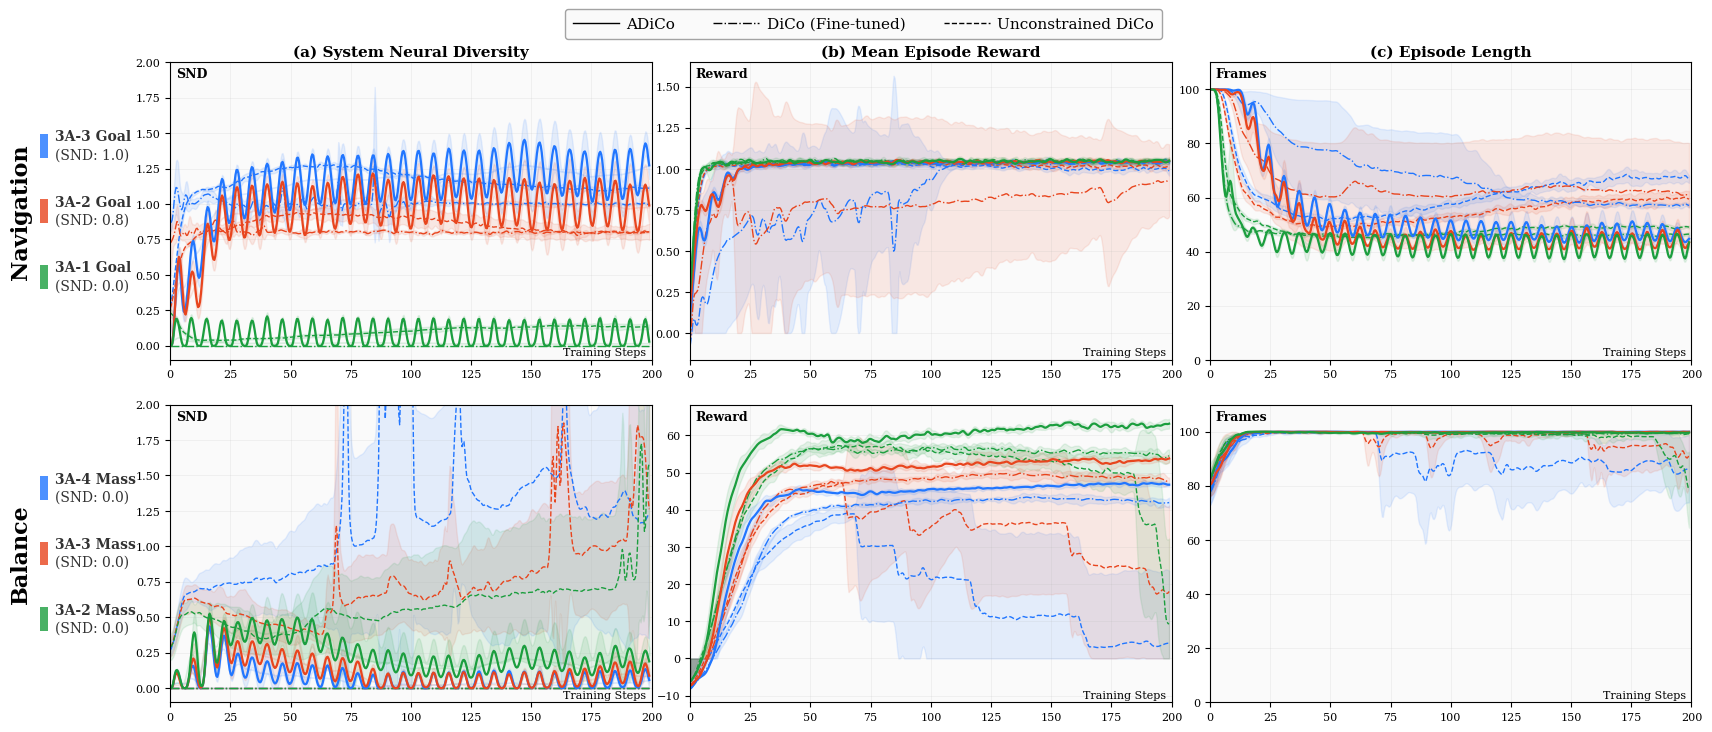

Saved fig1_combined.png/.pdf


In [11]:
# -- Load data -----------------------------------------------------

NAV_DIR = "navigation_data"
BAL_DIR = "balance_data"

def load_task_data(data_dir, tasks):
    data = {}
    for t in tasks:
        for method in ["ad2c", "dico", "unconstrained"]:
            dfs = load_csvs(data_dir, f"{method}_{t}_")
            if dfs:
                data[(method, t)] = dfs
                print(f"  {method} / {t}: {len(dfs)} seeds")
    return data

nav_data = load_task_data(NAV_DIR, ["3A-3G", "3A-2G", "3A-1G"])
bal_data = load_task_data(BAL_DIR, ["4M", "3M", "2M"])
print(f"\nNavigation: {len(nav_data)} combos | Balance: {len(bal_data)} combos")


# -- Config --------------------------------------------------------

NAV_COLORS = {"3A-3G": "#2176FF", "3A-2G": "#E8451E", "3A-1G": "#1B9E3E"}
BAL_COLORS = {"4M": "#2176FF", "3M": "#E8451E", "2M": "#1B9E3E"}

NAV_TASK_LABELS = {"3A-3G": "3A-3 Goal", "3A-2G": "3A-2 Goal", "3A-1G": "3A-1 Goal"}
BAL_TASK_LABELS = {"4M": "3A-4 Mass", "3M": "3A-3 Mass", "2M": "3A-2 Mass"}

NAV_LABELS = {
    ("ad2c","3A-3G"): "ADiCo (3A-3G)", ("ad2c","3A-2G"): "ADiCo (3A-2G)", ("ad2c","3A-1G"): "ADiCo (3A-1G)",
    ("dico","3A-3G"): "DiCo (3A-3G)", ("dico","3A-2G"): "DiCo (3A-2G)", ("dico","3A-1G"): "DiCo (3A-1G)",
    ("unconstrained","3A-3G"): "Uncons. (3A-3G)", ("unconstrained","3A-2G"): "Uncons. (3A-2G)", ("unconstrained","3A-1G"): "Uncons. (3A-1G)",
}
BAL_LABELS = {
    ("ad2c","4M"): "ADiCo (3A-4M)", ("ad2c","3M"): "ADiCo (3A-3M)", ("ad2c","2M"): "ADiCo (3A-2M)",
    ("dico","4M"): "DiCo (3A-4M)", ("dico","3M"): "DiCo (3A-3M)", ("dico","2M"): "DiCo (3A-2M)",
    ("unconstrained","4M"): "Uncons. (3A-4M)", ("unconstrained","3M"): "Uncons. (3A-3M)", ("unconstrained","2M"): "Uncons. (3A-2M)",
}


# -- Plot helper ---------------------------------------------------

def plot_metric(ax, data, tasks, colors, labels, metric_key,
                ylabel, ylim=None, show_setpoint=False, sw=5):
    col = METRICS[metric_key]
    for method in ["unconstrained", "dico", "ad2c"]:
        for t in tasks:
            key = (method, t)
            if key not in data: continue
            steps, mean, vmin, vmax = aggregate(data[key], col, sw=sw)
            if steps is None: continue
            ax.plot(steps, mean, color=colors[t], label=labels.get(key, f"{method} {t}"), **LINE_STYLES[method])
            if len(data[key]) > 1:
                ax.fill_between(steps, vmin, vmax, color=colors[t], alpha=0.10)
    if show_setpoint:
        for t in tasks:
            if ("ad2c", t) not in data: continue
            sp_s, sp_m = aggregate_setpoint(data[("ad2c", t)])
            if sp_s is None: continue
            ax.plot(sp_s, sp_m, color=colors[t], lw=1.2, alpha=0.15, zorder=1)
    ax.annotate(ylabel, xy=(0, 1), xycoords='axes fraction',
                xytext=(4, -4), textcoords='offset points',
                fontsize=9, fontweight='bold', ha='left', va='top')
    ax.set_ylabel('')
    ax.annotate('Training Steps', xy=(1, 0.06), xycoords='axes fraction',
                xytext=(-4, -4), textcoords='offset points',
                fontsize=8, ha='right', va='top')
    ax.set_xlim(left=0, right=200)
    if ylim: ax.set_ylim(ylim)


def draw_task_config(ax, task_labels, colors, task_keys, dico_snds):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    for i, t in enumerate(task_keys):
        y = 0.72 - i * 0.22
        color = colors[t]
        label = task_labels[t]
        snd_str = dico_snds.get(t, "")
        ax.add_patch(plt.Rectangle((0.05, y - 0.04), 0.08, 0.08,
                     facecolor=color, edgecolor='none', alpha=0.8))
        if snd_str:
            ax.text(0.20, y + 0.03, label, fontsize=10, fontweight='bold',
                    va='center', ha='left', color='#333333')
            ax.text(0.20, y - 0.03, f"(SND: {float(snd_str):.1f})", fontsize=10,
                    va='center', ha='left', color='#333333')
        else:
            ax.text(0.20, y, label, fontsize=10, fontweight='bold',
                    va='center', ha='left', color='#333333')


# -- Figure: 2x4 grid ---------------------------------------------

fig = plt.figure(figsize=(18, 8))

gs = fig.add_gridspec(2, 4, width_ratios=[0.6, 3, 3, 3],
                       left=0.04, right=0.96, bottom=0.08, top=0.88,
                       wspace=0.1, hspace=0.15)

# -- Row 0: Navigation --------------------------------------------
ax_nav_cfg = fig.add_subplot(gs[0, 0])
draw_task_config(ax_nav_cfg, NAV_TASK_LABELS, NAV_COLORS,
                 ["3A-3G", "3A-2G", "3A-1G"],
                 {"3A-3G": "1.0", "3A-2G": "0.8", "3A-1G": "0"})

ax_nav_snd = fig.add_subplot(gs[0, 1])
ax_nav_rew = fig.add_subplot(gs[0, 2])
ax_nav_epl = fig.add_subplot(gs[0, 3])

plot_metric(ax_nav_snd, nav_data, ["3A-3G","3A-2G","3A-1G"], NAV_COLORS, NAV_LABELS,
            "snd", "SND", ylim=(-0.1,2.0), show_setpoint=True, sw=3)
plot_metric(ax_nav_rew, nav_data, ["3A-3G","3A-2G","3A-1G"], NAV_COLORS, NAV_LABELS,
            "reward", "Reward")
plot_metric(ax_nav_epl, nav_data, ["3A-3G","3A-2G","3A-1G"], NAV_COLORS, NAV_LABELS,
            "epl", "Frames", ylim=(0, 110))

# Subtitles above Navigation row
subtitles = ['(a) System Neural Diversity', '(b) Mean Episode Reward', '(c) Episode Length']
for ax, sub in zip([ax_nav_snd, ax_nav_rew, ax_nav_epl], subtitles):
    ax.set_title(sub, fontsize=11, fontweight='bold', pad=4)

# -- Row 1: Balance ------------------------------------------------
ax_bal_cfg = fig.add_subplot(gs[1, 0])
draw_task_config(ax_bal_cfg, BAL_TASK_LABELS, BAL_COLORS,
                 ["4M", "3M", "2M"],
                 {"4M": "0", "3M": "0", "2M": "0"})

ax_bal_snd = fig.add_subplot(gs[1, 1])
ax_bal_rew = fig.add_subplot(gs[1, 2])
ax_bal_epl = fig.add_subplot(gs[1, 3])

plot_metric(ax_bal_snd, bal_data, ["4M","3M","2M"], BAL_COLORS, BAL_LABELS,
            "snd", "SND", ylim=(-0.1,2.0), show_setpoint=True, sw=3)
plot_metric(ax_bal_rew, bal_data, ["4M","3M","2M"], BAL_COLORS, BAL_LABELS,
            "reward", "Reward")
plot_metric(ax_bal_epl, bal_data, ["4M","3M","2M"], BAL_COLORS, BAL_LABELS,
            "epl", "Frames", ylim=(0, 110))

# -- Row labels (left side) ----------------------------------------
ax_nav_cfg.text(-0.15, 0.5, 'Navigation', fontsize=16, fontweight='bold',
                rotation=90, va='center', ha='center', transform=ax_nav_cfg.transAxes)
ax_bal_cfg.text(-0.15, 0.5, 'Balance', fontsize=16, fontweight='bold',
                rotation=90, va='center', ha='center', transform=ax_bal_cfg.transAxes)

# -- Top legend ----------------------------------------------------
legend_handles = [
    mlines.Line2D([], [], color='black', linestyle='-',  linewidth=1.0, label='ADiCo'),
    mlines.Line2D([], [], color='black', linestyle='-.', linewidth=1.0, label='DiCo (Fine-tuned)'),
    mlines.Line2D([], [], color='black', linestyle="--", linewidth=1.0, label='Unconstrained DiCo'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, 0.9),
           fontsize=11, frameon=True, fancybox=True, edgecolor='#999999',
           framealpha=0.9, columnspacing=2.5, handlelength=3.0,
           handletextpad=0.5, borderpad=0.5)

for ext in ['png', 'pdf']:
    fig.savefig(f"fig1_combined.{ext}", dpi=300, bbox_inches='tight')
plt.show()
print("Saved fig1_combined.png/.pdf")

---
# Plot 2: Convergence Analysis

In [13]:
import pandas as pd
import wandb
import os

api = wandb.Api()

def download_runs(project, run_map, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    runs = api.runs(project)
    lookup = {r.name: r for r in runs}
    print(f"  {project}: {len(lookup)} runs found")

    for fname, run_name in run_map.items():
        if run_name not in lookup:
            print(f"    MISSING: {run_name}")
            continue
        df = lookup[run_name].history(samples=10000)
        path = os.path.join(output_dir, f"{fname}.csv")
        df.to_csv(path, index=False)
        print(f"    {run_name} -> {path} ({len(df)} rows)")


NAV_PROJECT = "svarp-university-of-massachusetts-lowell/Navigation"
conv_runs = {}

# -- ADCo: 5 seeds each at SND = 0, 0.5, 1 --
for snd in ["0", "0.5", "1"]:
    for s in range(5):
        conv_runs[f"adco_snd{snd}_seed{s}"] = f"nav_ad2c_3a3g_{snd}_seed{s}"

# -- DiCo SND=1.0: seed 1 only --
for s in [1,2,4]:
    conv_runs[f"dico_snd1p0_seed{s}"] = f"nav_dico_3a3g_1_seed{s}"

# -- DiCo SND=0.5: seeds 0, 2 --
for s in [0, 2]:
    conv_runs[f"dico_snd0p5_seed{s}"] = f"nav_dico_3a3g_0.5_seed{s}"

# -- DiCo SND=0: seeds 0, 1, 2, 3 --
for s in [0, 1, 2, 3]:
    conv_runs[f"dico_snd0p0_seed{s}"] = f"nav_dico_3a3g_0_seed{s}"

print("Downloading Convergence data...")
download_runs(NAV_PROJECT, conv_runs, "convergence_data")
print("Done.")

  svarp-university-of-massachusetts-lowell/Navigation: 127 runs found
    nav_ad2c_3a3g_0_seed0 -> convergence_data/adco_snd0_seed0.csv (200 rows)
    nav_ad2c_3a3g_0_seed1 -> convergence_data/adco_snd0_seed1.csv (200 rows)
    nav_ad2c_3a3g_0_seed2 -> convergence_data/adco_snd0_seed2.csv (200 rows)
    nav_ad2c_3a3g_0_seed3 -> convergence_data/adco_snd0_seed3.csv (200 rows)
    nav_ad2c_3a3g_0_seed4 -> convergence_data/adco_snd0_seed4.csv (200 rows)
    nav_ad2c_3a3g_0.5_seed0 -> convergence_data/adco_snd0.5_seed0.csv (200 rows)
    nav_ad2c_3a3g_0.5_seed1 -> convergence_data/adco_snd0.5_seed1.csv (200 rows)
    nav_ad2c_3a3g_0.5_seed2 -> convergence_data/adco_snd0.5_seed2.csv (200 rows)
    nav_ad2c_3a3g_0.5_seed3 -> convergence_data/adco_snd0.5_seed3.csv (200 rows)
    nav_ad2c_3a3g_0.5_seed4 -> convergence_data/adco_snd0.5_seed4.csv (200 rows)
    nav_ad2c_3a3g_1_seed0 -> convergence_data/adco_snd1_seed0.csv (200 rows)
    nav_ad2c_3a3g_1_seed1 -> convergence_data/adco_snd1_seed1.c

Text(0.5, 1.0, '(c) Episode Length')

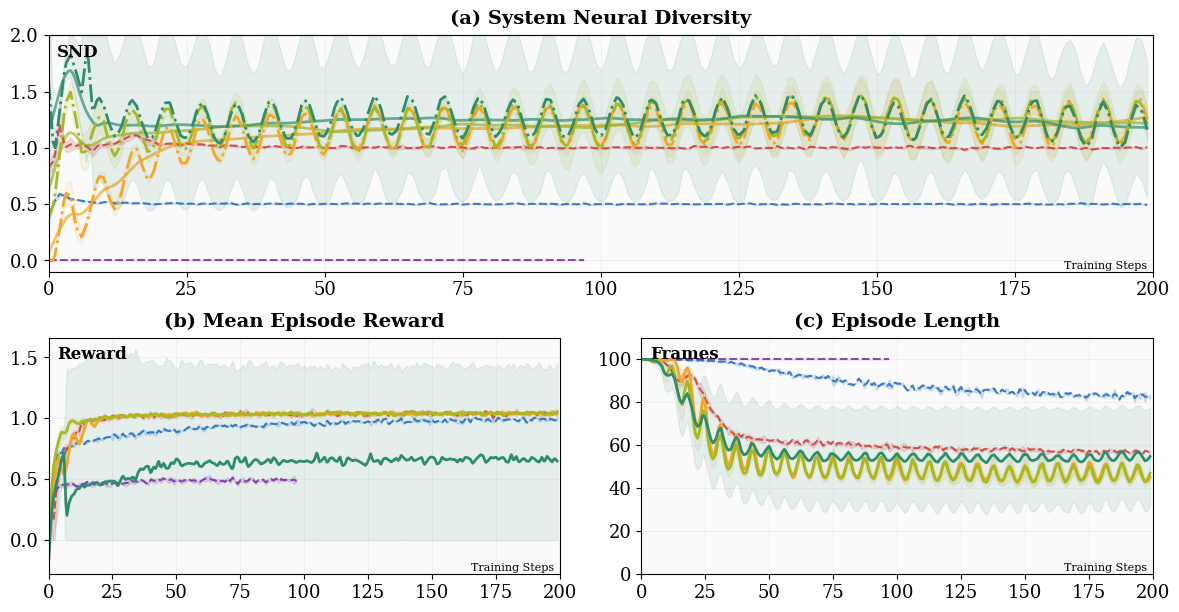

In [27]:
# -- Plot helper ---------------------------------------------------

def plot_conv_metric(ax, conv_data, dico_conv_data, mkey,
                     ylabel, sw, ylim=None, show_setpoint=False):
    col = METRICS[mkey]

    for k, label in DICO_SNDS.items():
        if k not in dico_conv_data:
            continue

        steps, mean, vmin, vmax = aggregate(
            dico_conv_data[k], col, sw=sw
        )
        if steps is None:
            continue

        ax.plot(
            steps, mean,
            color=DICO_COLORS[k],
            lw=1.5,
            label=label,
            linestyle="--",
            alpha=0.8,
        )

        if len(dico_conv_data[k]) > 1:
            ax.fill_between(
                steps, vmin, vmax,
                color=DICO_COLORS[k],
                alpha=0.15,
            )

    for k, label in ADCO_SNDS.items():
        if k not in conv_data:
            continue

        steps, mean, vmin, vmax = aggregate(
            conv_data[k], col, sw=sw
        )
        if steps is None:
            continue

        ax.plot(
            steps, mean,
            color=ADCO_COLORS[k],
            lw=2.0,
            label=label,
            linestyle="-." if mkey == "snd" else "-",
        )

        if len(conv_data[k]) > 1:
            ax.fill_between(
                steps, vmin, vmax,
                color=ADCO_COLORS[k],
                alpha=0.10,
            )

        if show_setpoint and mkey == "snd":
            sp_s, sp_m = aggregate_setpoint(conv_data[k])
            if sp_s is not None:
                ax.plot(
                    sp_s, sp_m,
                    color=ADCO_COLORS[k],
                    lw=2.0,
                    alpha=0.7,
                    zorder=1,
                    linestyle="-",
                )

    # Labels at the top inside each panel.
    ax.annotate(
        ylabel,
        xy=(0, 1),
        xycoords="axes fraction",
        xytext=(6, -6),
        textcoords="offset points",
        fontsize=12,
        fontweight="bold",
        ha="left",
        va="top",
    )

    ax.annotate(
        "Training Steps",
        xy=(1, 0),
        xycoords="axes fraction",
        xytext=(-4, 8),
        textcoords="offset points",
        fontsize=8,
        ha="right",
        va="top",
    )

    ax.set_ylabel("")
    ax.set_xlabel("")

    # Larger axis numbers.
    ax.tick_params(axis="both", labelsize=13)

    # Original constraints.
    ax.set_xlim(0, 200)
    if ylim is not None:
        ax.set_ylim(ylim)

    # Preserve all four borders.
    for spine in ax.spines.values():
        spine.set_visible(True)


# -- Figure --------------------------------------------------------

fig = plt.figure(figsize=(12, 7))

gs = fig.add_gridspec(
    2, 2,
    height_ratios=[1, 1],
    left=0.06,
    right=0.98,
    bottom=0.06,
    top=0.83,
    wspace=0.16,
    hspace=0.28,
)

ax_snd = fig.add_subplot(gs[0, :])
plot_conv_metric(
    ax_snd, conv_data, dico_conv_data,
    "snd", "SND",
    sw=0,
    ylim=(-0.1, 2.0),
    show_setpoint=True,
)
ax_snd.set_title(
    "(a) System Neural Diversity",
    fontsize=14,
    fontweight="bold",
    pad=8,
)

ax_rew = fig.add_subplot(gs[1, 0])
plot_conv_metric(
    ax_rew, conv_data, dico_conv_data,
    "reward", "Reward",
    sw=0,
)
ax_rew.set_title(
    "(b) Mean Episode Reward",
    fontsize=14,
    fontweight="bold",
    pad=8,
)

ax_epl = fig.add_subplot(gs[1, 1])
plot_conv_metric(
    ax_epl, conv_data, dico_conv_data,
    "epl", "Frames",
    sw=0,
    ylim=(0, 110),
)
ax_epl.set_title(
    "(c) Episode Length",
    fontsize=14,
    fontweight="bold",
    pad=8,
)

# Keep your existing legend and save sections below this.

---
# Plot 3: Stability Analysis

  AD2C 3A-3G: 5 seeds
  AD2C 3A-2G: 5 seeds
  AD2C 3A-1G: 5 seeds
  Stable 3A-3G: 5 seeds
  Stable 3A-2G: 5 seeds
  Stable 3A-1G: 5 seeds


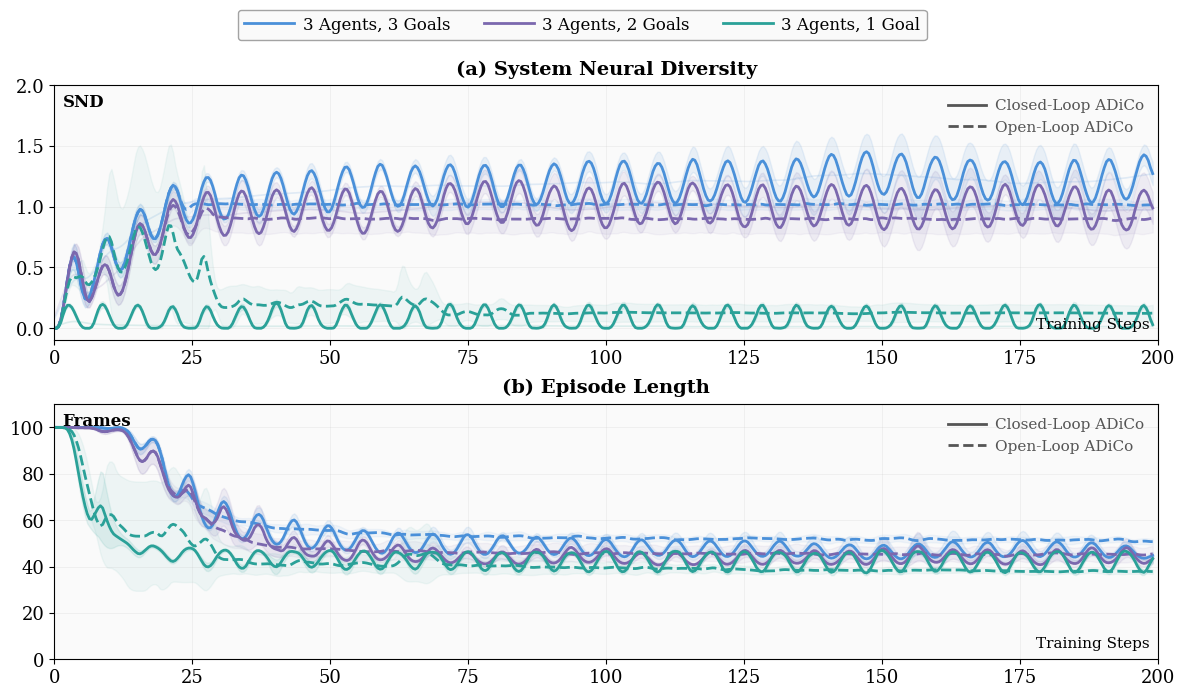

Saved stability_nav.png/.pdf


In [24]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines


# -- Config --------------------------------------------------------

NAV_DIR = "navigation_data"
STAB_DIR = "stability_data"
TASKS = ["3A-3G", "3A-2G", "3A-1G"]

STAB_COLORS = {
    "3A-3G": "#4A90D9",
    "3A-2G": "#7B68AE",
    "3A-1G": "#2AA198",
}

TASK_LABELS = {
    "3A-3G": "3 Agents, 3 Goals",
    "3A-2G": "3 Agents, 2 Goals",
    "3A-1G": "3 Agents, 1 Goal",
}


# -- Load data -----------------------------------------------------

# Uses your existing load_csvs, aggregate, aggregate_setpoint,
# and METRICS definitions.

ad2c = {}
for t in TASKS:
    dfs = load_csvs(NAV_DIR, f"ad2c_{t}_")
    if dfs:
        ad2c[t] = dfs
        print(f"  AD2C {t}: {len(dfs)} seeds")

stable = {}
for t in TASKS:
    dfs = load_csvs(STAB_DIR, f"stable_{t}_")
    if dfs:
        stable[t] = dfs
        print(f"  Stable {t}: {len(dfs)} seeds")


# -- Plot helper ---------------------------------------------------

def plot_stab_metric(ax, ad2c, stable, mkey, ylabel, sw, ylim=None):
    col = METRICS[mkey]

    for t in TASKS:
        c = STAB_COLORS[t]

        if t in ad2c:
            steps, mean, vmin, vmax = aggregate(
                ad2c[t], col, sw=sw
            )

            if steps is not None:
                ax.plot(
                    steps, mean,
                    color=c,
                    lw=2.0,
                    linestyle="-",
                )

                ax.fill_between(
                    steps, vmin, vmax,
                    color=c,
                    alpha=0.10,
                )

                if mkey == "snd":
                    sp_s, sp_m = aggregate_setpoint(ad2c[t])

                    if sp_s is not None:
                        ax.plot(
                            sp_s, sp_m,
                            color=c,
                            lw=1.2,
                            alpha=0.15,
                            zorder=1,
                        )

        if t in stable:
            steps, mean, vmin, vmax = aggregate(
                stable[t], col, sw=sw
            )

            if steps is not None:
                ax.plot(
                    steps, mean,
                    color=c,
                    lw=2.0,
                    linestyle="--",
                )

                if len(stable[t]) > 1:
                    ax.fill_between(
                        steps, vmin, vmax,
                        color=c,
                        alpha=0.06,
                    )

    # Metric label inside the top-left corner.
    ax.annotate(
        ylabel,
        xy=(0, 1),
        xycoords="axes fraction",
        xytext=(6, -6),
        textcoords="offset points",
        fontsize=12,
        fontweight="bold",
        ha="left",
        va="top",
    )
    ax.set_ylabel("")

    # Method legend with actual solid and dashed line samples.
    method_handles = [
        mlines.Line2D(
            [], [],
            color="#555555",
            linewidth=2.0,
            linestyle="-",
            label="Closed-Loop ADiCo",
        ),
        mlines.Line2D(
            [], [],
            color="#555555",
            linewidth=2.0,
            linestyle="--",
            label="Open-Loop ADiCo",
        ),
    ]

    ax.legend(
        handles=method_handles,
        loc="upper right",
        fontsize=11,
        frameon=False,
        handlelength=2.5,
        handletextpad=0.6,
        borderaxespad=0.5,
        labelcolor="#555555",
    )

    # Training Steps inside the bottom-right corner.
    ax.annotate(
        "Training Steps",
        xy=(1, 0),
        xycoords="axes fraction",
        xytext=(-6, 6),
        textcoords="offset points",
        fontsize=11,
        ha="right",
        va="bottom",
    )
    ax.set_xlabel("")

    # Larger tick numbers.
    ax.tick_params(axis="both", labelsize=13)

    # Original axis constraints.
    ax.set_xlim(0, 200)
    if ylim is not None:
        ax.set_ylim(ylim)

    # Preserve all four plot borders.
    for spine in ax.spines.values():
        spine.set_visible(True)


# -- Figure --------------------------------------------------------

fig = plt.figure(figsize=(12, 7))

gs = fig.add_gridspec(
    2, 1,
    height_ratios=[1, 1],
    left=0.06,
    right=0.98,
    bottom=0.06,
    top=0.88,
    hspace=0.25,
)

# Top: SND
ax_snd = fig.add_subplot(gs[0])

plot_stab_metric(
    ax_snd,
    ad2c,
    stable,
    "snd",
    "SND",
    sw=3,
    ylim=(-0.1, 2.0),
)

ax_snd.set_title(
    "(a) System Neural Diversity",
    fontsize=14,
    fontweight="bold",
    pad=8,
)

# Bottom: Episode Length
ax_epl = fig.add_subplot(gs[1])

plot_stab_metric(
    ax_epl,
    ad2c,
    stable,
    "epl",
    "Frames",
    sw=5,
    ylim=(0, 110),
)

ax_epl.set_title(
    "(b) Episode Length",
    fontsize=14,
    fontweight="bold",
    pad=8,
)


# -- Top legend: task colors ---------------------------------------

legend_handles = [
    mlines.Line2D(
        [], [],
        color=STAB_COLORS[t],
        linestyle="-",
        linewidth=2.0,
        label=TASK_LABELS[t],
    )
    for t in TASKS
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, 1.0),
    fontsize=12,
    frameon=True,
    fancybox=True,
    edgecolor="#999999",
    framealpha=0.9,
    columnspacing=2.0,
    handlelength=3.0,
    handletextpad=0.5,
    borderpad=0.4,
)


# -- Save ----------------------------------------------------------

for ext in ["png", "pdf"]:
    fig.savefig(
        f"stability_nav.{ext}",
        dpi=800,
        bbox_inches="tight",
    )

plt.show()
print("Saved stability_nav.png/.pdf")

# Deleting the problematic Runs